__Markus Mulvihill__

__Last updated April 2026__

# Necessary Packages and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
from matplotlib import rcParams

# Introduction

Within this file, different methods of parameter estimation will be implemented and compared to predict the Insulin Sensitivity $\, SI$ in patients

# Constant SI with State Augmentation

In [2]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_static_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_static_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_augment_static_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment.py")

Loaded variables


In [3]:
FIG_WIDTH = 7.5  # width of figure in inches

TINY_SIZE = 6
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=TINY_SIZE, titleweight="bold")  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=TINY_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False

In [4]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "04"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
dev_perc = cfg[curr_module]["dev_perc"]
deviations = cfg[curr_module]["deviations"]
num_deviations = len(deviations)

filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)

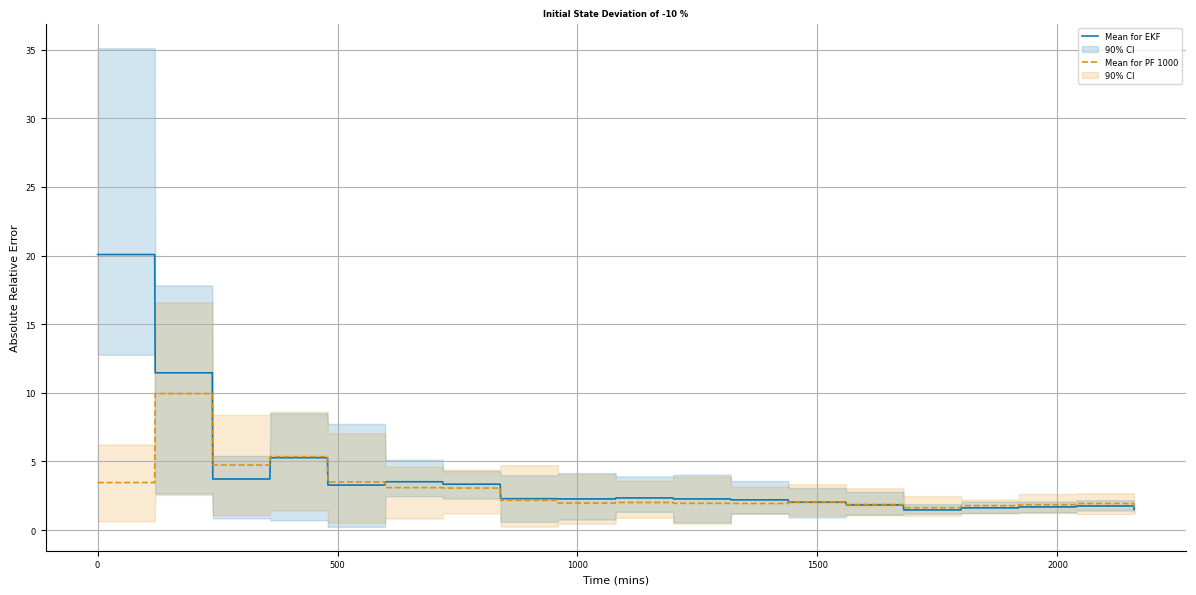

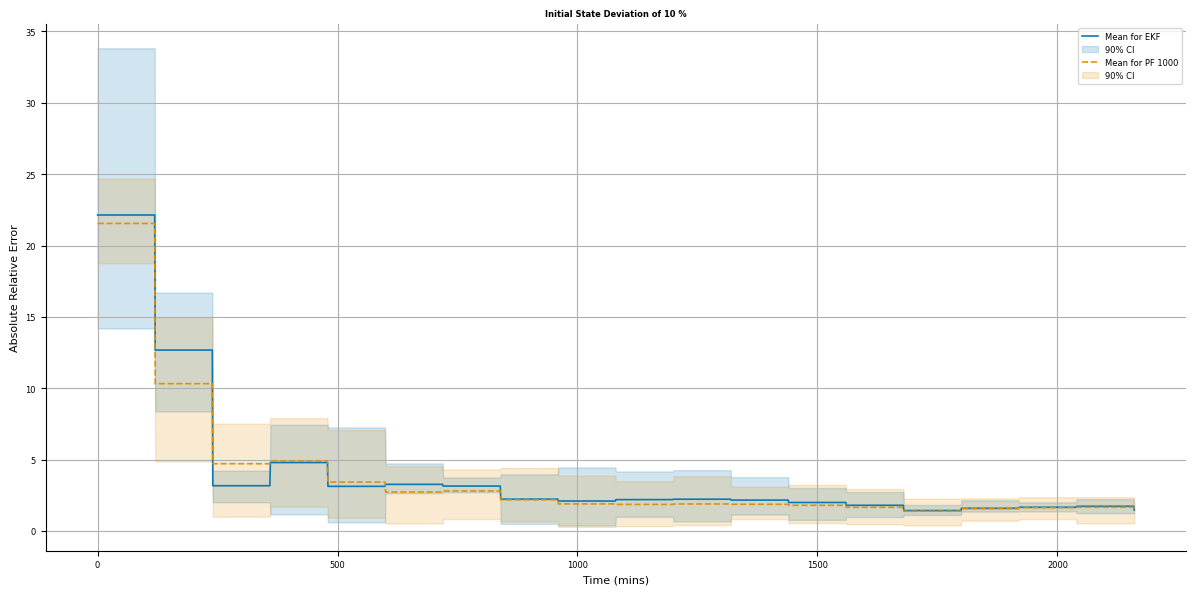

In [5]:
for j in range(num_deviations):
    mean_err = np.mean(SI_errs[j, :, :, :], axis=1)
    ci_low = np.percentile(SI_errs[j, :, :, :], low_perc, axis=1)
    ci_high = np.percentile(SI_errs[j, :, :, :], high_perc, axis=1)
    time = np.arange(mean_err.shape[1])
    num_plots = len(filters)
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters)

    fig, ax = plt.subplots(figsize=(12, 6))

    for i in range(num_plots):
        ax.plot(
            time,
            mean_err[i],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"Mean for {filters[i]}",
        )
        ax.fill_between(
            time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18, label=f"{CI}% CI"
        )
    ax.set_ylabel("Absolute Relative Error")
    ax.legend(loc="best")
    ax.set_xlabel("Time (mins)")
    ax.set_title(f"Initial State Deviation of {dev_perc[j]} %")
    ax.grid()
    fig.tight_layout()

# Changing SI with State Augmentation 

In [6]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_vary_04.npy")
    SI_vars = np.load("../scripts/variables/SI_vars_augment_vary_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_vary_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_augment_vary_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment_vary.py")

Loaded variables


In [7]:
SI_ests.shape

(2, 2, 5, 2161)

<>:13: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:26: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:13: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:26: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/2r/d34tnm611fn3fckxlfmjl03r0000gn/T/ipykernel_92624/1558972195.py:13: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  est, lower, upper, label="2 $\sigma$", alpha=0.18, color="orange"
/var/folders/2r/d34tnm611fn3fckxlfmjl03r0000gn/T/ipykernel_92624/1558972195.py:26: Syn

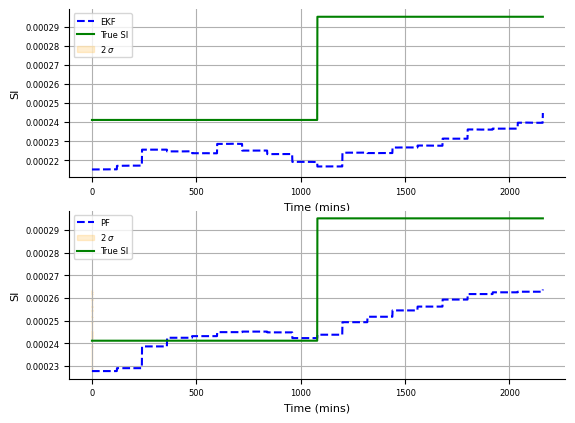

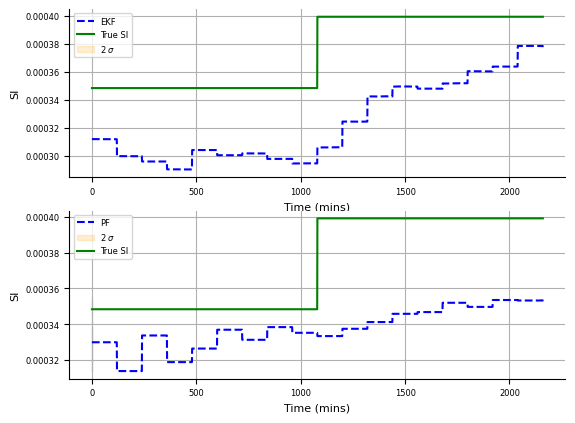

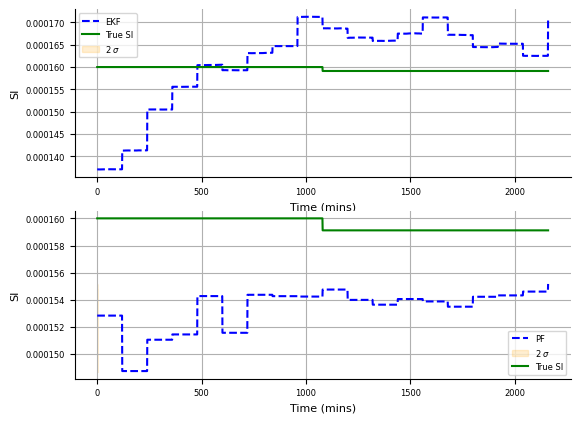

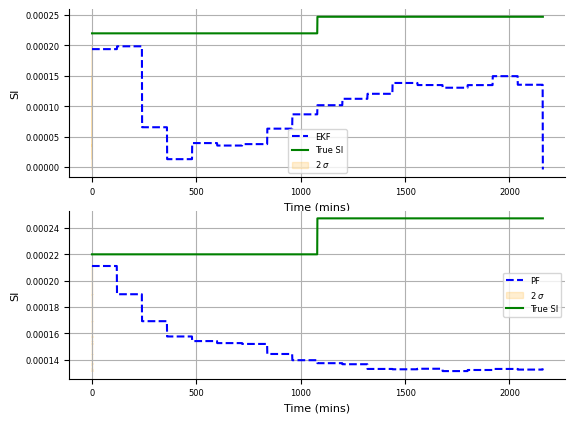

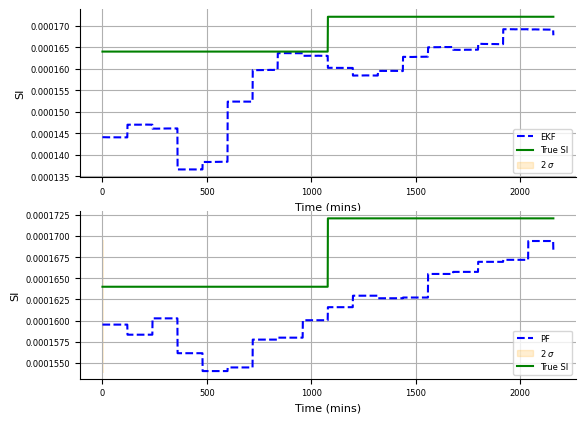

In [8]:
for i in range(SI_true_arr.shape[0]):
    patient = i
    deviation = 0
    fig, ax = plt.subplots(2, 1)
    est = SI_ests[deviation, 0, patient, :]
    true_SI = SI_true_arr[patient, :]
    std = 2 * np.sqrt(SI_vars[deviation, 0, patient, :])
    upper = est + 2 * std
    lower = est - 2 * std
    ax[0].plot(time, est, "b--", label="EKF")
    ax[0].plot(time, true_SI, color="green", label="True SI")
    ax[0].fill_betweenx(
        est, lower, upper, label="2 $\sigma$", alpha=0.18, color="orange"
    )
    ax[0].set_xlabel('Time (mins)')
    ax[0].set_ylabel('SI')
    ax[0].grid()
    ax[0].legend()

    est = SI_ests[deviation, 1, patient, :]
    std = 2 * np.sqrt(SI_vars[deviation, 1, patient, :])
    upper = est + 2 * std
    lower = est - 2 * std
    ax[1].plot(time, est, "b--", label="PF")
    ax[1].fill_betweenx(
        est, lower, upper, label="2 $\sigma$", alpha=0.18, color="orange"
    )
    ax[1].plot(time, true_SI, color="green", label="True SI")
    ax[1].grid()
    ax[1].legend()
    ax[1].set_xlabel('Time (mins)')
    ax[1].set_ylabel('SI')

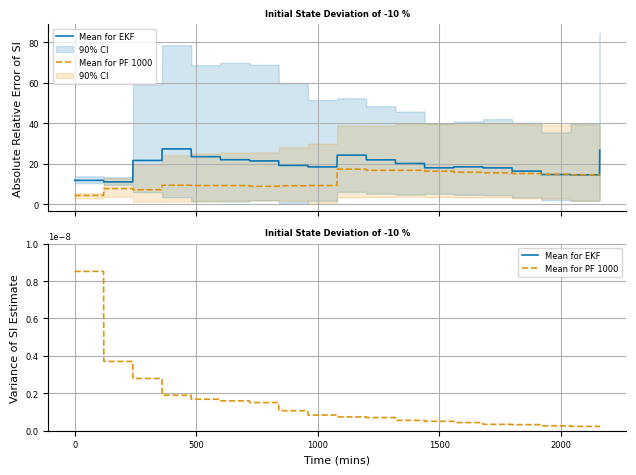

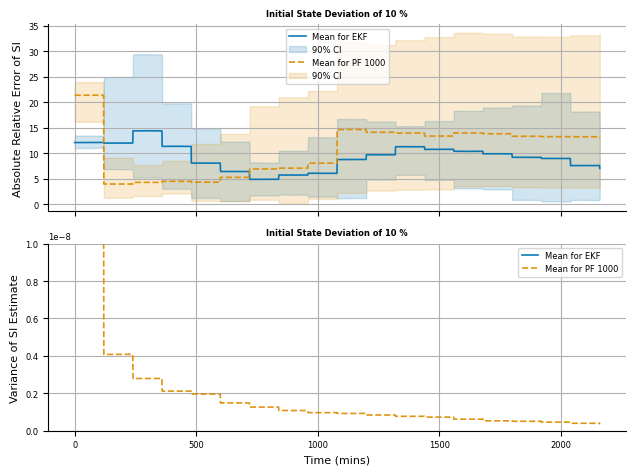

In [9]:
for j in range(num_deviations):
    mean_err = np.mean(SI_errs[j, :, :, :], axis=1)
    mean_var = np.abs(np.mean(SI_vars[j, :, :, :], axis=1))

    ci_low = np.percentile(SI_errs[j, :, :, :], low_perc, axis=1)
    ci_high = np.percentile(SI_errs[j, :, :, :], high_perc, axis=1)
    time = np.arange(mean_err.shape[1])
    num_plots = len(filters)
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters)

    fig, ax = plt.subplots(2, 1, sharex=True)

    for i in range(num_plots):
        ax[0].plot(
            time,
            mean_err[i],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"Mean for {filters[i]}",
        )
        ax[0].fill_between(
            time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18, label=f"{CI}% CI"
        )
        ax[1].plot(
            time,
            mean_var[i],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"Mean for {filters[i]}",
        )

    ax[0].set_ylabel("Absolute Relative Error of SI")
    ax[0].legend(loc="best")
    ax[0].set_title(f"Initial State Deviation of {dev_perc[j]} %")
    ax[0].grid()

    ax[1].set_ylabel("Variance of SI Estimate")
    ax[1].set_xlabel("Time (mins)")
    ax[1].legend(loc="best")
    ax[1].set_title(f"Initial State Deviation of {dev_perc[j]} %")
    ax[1].grid()
    ax[1].set_ylim([0, 1e-8])
    fig.tight_layout()